### Selecting Physical System and Run with Classical ODE Solve Method (20 pts)

Problem: Damped harmonic oscillator

Equation of motion is given by

$$
\begin{gather*}
m\ddot{x}=-kx-b\dot{x}\\
\ddot{x}+2\gamma\dot{x}+\omega^2x=0
\end{gather*}
$$
with $\omega_0^2=k/m$ and $\gamma=b/(2m)$. We can solve this problem using ansatz: $x(t)=e^{\lambda t}$. Therefore,
$$
\begin{align*}
(\lambda^2+2\gamma\lambda+\omega_0^2)x=0
\end{align*}
$$
The non trivial solution is given as
$$
\begin{gather*}
\lambda=-\gamma\pm\sqrt{\gamma^2-\omega_0^2}\\
\therefore x(t)=Ae^{(-\gamma+\sqrt{\gamma^2-\omega_0^2})t} + Be^{(-\gamma-\sqrt{\gamma^2-\omega_0^2})t}
\end{gather*}
$$
In this note, we treat only underdamped case, $\gamma^2<\omega_0^2$. Defining $\omega=\sqrt{\omega_0^2-\gamma^2}$, we have the general solution as
$$
\begin{align*}
x(t)=Ae^{(-\gamma+i\omega)t} + Be^{(-\gamma-i\omega)t}=e^{-\gamma t}(Ae^{i\omega t}+Be^{-i\omega t})=Ce^{-\gamma t}\cos(\omega t+\phi)
\end{align*}
$$
Here, $C$ and $\phi$ will be determined by initial conditions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# INITIAL CONDITIONS
x0 = 2.0 # Initial condition of x
v0 = 1.0 # Initial condition of v
w0 = 1.0 # \omega_0
g = 0.1 # \gamma
w = np.sqrt(w0**2 - g**2) # \omega=\sqrt{\omega_0^2-\gamma^2}

# ODE FUNCTION

def f(r, t, w0, g):
    r_new = np.zeros((r.shape[0]), dtype=float)
    r_new[0] = r[1]
    r_new[1] = -w0*r[0] - 2*g*r[1]

    return r_new

In [2]:
# SELECTED CLASSICAL METHOD FOR SOLVING ODE: RK4

def RK4(f, r, t, h, w0=w0, g=g):
    k1 = h*f(r, t, w0, g)
    k2 = h*f(r + 0.5*k1, t + 0.5*h, w0, g)
    k3 = h*f(r + 0.5*k2, t + 0.5*h, w0, g)
    k4 = h*f(r + k3, t + h, w0, g)

    return r + (k1 + 2*k2 + 2*k3 + k4)/6.0

In [3]:
# SOLVE ODE
h = 0.01 # Time step
t = np.arange(0, 40+h, h) # Time
r = np.zeros((2, t.size), dtype=float)
# r[0] = x, position
# r[1] = v, velocity
r[0, 0] = x0
r[1, 0] = v0

for i, t_i in enumerate(range(t.size - 1)):
    r[:, i+1] = RK4(f, r[:, i], t_i, h)

x = r[0]

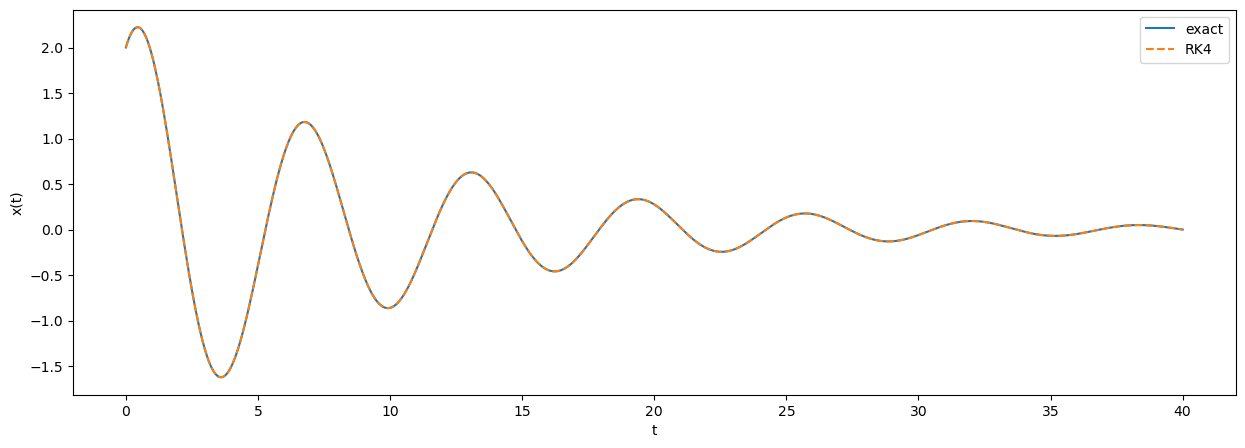

In [5]:
# VISUALIZATION
phi = np.arctan(-(g + v0/x0)/w)
C = x0/np.cos(phi)
x_exact = C*np.exp(-g*t)*np.cos(w*t + phi) # Exact solution

plt.figure(figsize=(15, 5))
plt.plot(t, x_exact, label="exact")
plt.plot(t, x, '--', label="RK4")
plt.xlabel("t")
plt.ylabel("x(t)")

plt.legend()
plt.show()


### Run with Simple NN (20pts)

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim

# SELECTED NEURAL NETWORK FOR SOLVING ODE

class pinn_model(nn.Module):
    def __init__(self, w0, g):
        super().__init__()
        self.w0 = w0
        self.g = g
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        self.apply(self._init_weights) # Recursively traverse and check all sub-modules inheriting from nn.Module

    def _init_weights(self, layer):
        # Initialization of weights and biases
        if isinstance(layer, nn.Linear):
            nn.init.xavier_uniform_(layer.weight)
            nn.init.constant_(layer.bias, 0.0)


    def _lossFunction(self, t, x0, v0, x_pred):
        # t: time
        # x0: Initial value of x
        # v0: Inivial value of v
        # x_pred: prediction value of x
        # v_pred: prediction vlaue of v

        # dx/dt
        dx = torch.autograd.grad(
            outputs=x_pred,
            inputs=t,
            grad_outputs=torch.ones_like(x_pred),
            create_graph=True,
            retain_graph=True
        )[0]

        #d^2x/dt^2
        ddx = torch.autograd.grad(
            outputs=dx,
            inputs=t,
            grad_outputs=torch.ones_like(dx),
            create_graph=True,
            retain_graph=True
        )[0]

        ode = ddx + 2*self.g*dx + self.w0*self.w0*x_pred
        L_ODE = nn.MSELoss()(ode, torch.zeros_like(ode))
        L_initial = nn.MSELoss()(x_pred[0], x0) + nn.MSELoss()(dx[0], v0)

        return L_ODE + L_initial


    def run_train(self, x0, v0, T, N, epochs, lr=0.001):
        x0 = torch.tensor([x0], dtype=torch.float32)
        v0 = torch.tensor([v0], dtype=torch.float32)
        t = torch.linspace(0, T, N).view(-1, 1).requires_grad_(True)
        optimizer = optim.Adam(self.net.parameters(), lr=lr)
        loss_list = np.zeros(epochs)

        for epoch in range(epochs):
            optimizer.zero_grad()
            x_pred = self.net(t)
            loss = self._lossFunction(t, x0, v0, x_pred)
            loss.backward()
            optimizer.step()
            loss_list[epoch] = loss.item()

            if (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")

        return loss_list
    

    def prediction(self, t):
        t = torch.from_numpy(t).float().view(-1, 1)
        with torch.no_grad():
            predictions = self.net(t)

            return predictions

In [ ]:
# DEFINE RESIDUAL FUNCTION

# YOUR RESIDUAL FUNCTION CODE HERE 

In [ ]:
# DATASET GENERATION

# YOUR DATASET GENERATION CODE HERE

Epoch 100/10000, Loss: 4.93566370010376
Epoch 200/10000, Loss: 4.9335455894470215
Epoch 300/10000, Loss: 4.930599212646484
Epoch 400/10000, Loss: 4.926113128662109
Epoch 500/10000, Loss: 4.918224334716797
Epoch 600/10000, Loss: 4.899913787841797
Epoch 700/10000, Loss: 4.849997520446777
Epoch 800/10000, Loss: 4.734584331512451
Epoch 900/10000, Loss: 4.488708019256592
Epoch 1000/10000, Loss: 4.069457054138184
Epoch 1100/10000, Loss: 3.6744091510772705
Epoch 1200/10000, Loss: 3.354808807373047
Epoch 1300/10000, Loss: 3.0843212604522705
Epoch 1400/10000, Loss: 2.7937653064727783
Epoch 1500/10000, Loss: 2.628026008605957
Epoch 1600/10000, Loss: 2.3508901596069336
Epoch 1700/10000, Loss: 2.158228874206543
Epoch 1800/10000, Loss: 1.9422361850738525
Epoch 1900/10000, Loss: 1.5092697143554688
Epoch 2000/10000, Loss: 0.7293311357498169
Epoch 2100/10000, Loss: 0.24828562140464783
Epoch 2200/10000, Loss: 0.12137600034475327
Epoch 2300/10000, Loss: 0.07106129825115204
Epoch 2400/10000, Loss: 0.0482

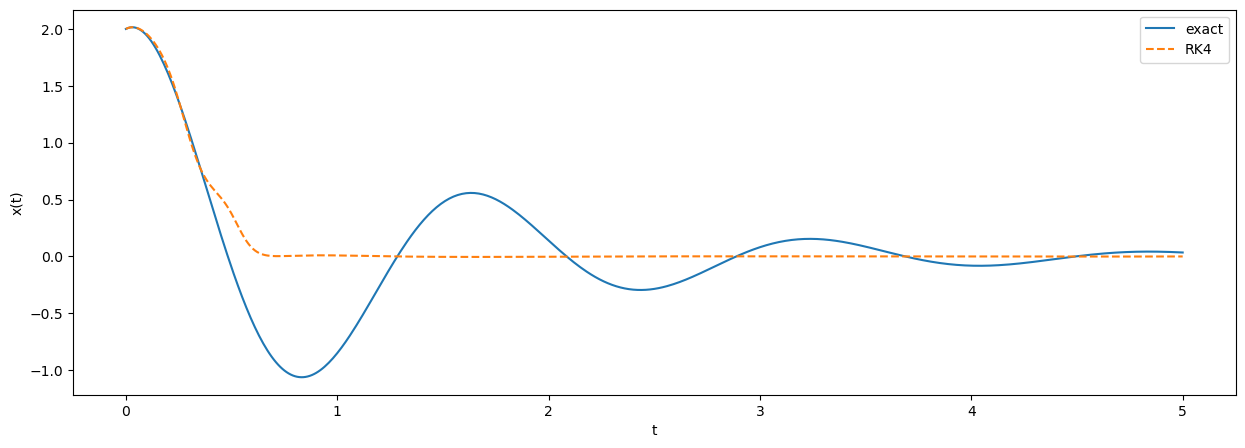

In [36]:
# TRAINING NEURAL NETWORK

# INITIAL CONDITIONS
x0 = 2.0 # Initial condition of x
v0 = 1.0 # Initial condition of v
w0 = 4.0 # \omega_0
g = 0.8 # \gamma
w = np.sqrt(w0**2 - g**2) # \omega=\sqrt{\omega_0^2-\gamma^2}

h = 0.01 # Time step
t = np.arange(0, 5+h, h) # Time
phi = np.arctan(-(g + v0/x0)/w)
C = x0/np.cos(phi)
x_exact = C*np.exp(-g*t)*np.cos(w*t + phi) # Exact solution

pinn = pinn_model(w0, g)
loss_list = pinn.run_train(x0, v0, 5, 20, 10000)
x_pinn = pinn.prediction(t)

plt.figure(figsize=(15, 5))
plt.plot(t, x_exact, label="exact")
plt.plot(t, x_pinn, '--', label="RK4")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()

plt.show()


### Analysis Classical Method and Deep Learning Based Method (30pts)

YOUR SELECTED ANALYSIS METHOD (OR ANALYSIS PARAMETERS) EXPLANATION HERE (in markdown)

In [ ]:
# ANALYSIS

# YOUR ANALYSIS CODE HERE

In [ ]:
# VISUALIZATION

# YOUR VISUALIZATION FOR ANALYSIS CODE HERE

### Discuss the results (30pts)

DISCUSSING THE ANALYSIS RESULTS (in 200 words)